In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Load Dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Shape of Features:", X.shape)
print("Shape of Target:", y.shape)

Shape of Features: (569, 30)
Shape of Target: (569,)


In [3]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#Neural Network with ReLU
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

relu_model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    max_iter=300,
    random_state=42
)

relu_model.fit(X_train, y_train)

relu_pred = relu_model.predict(X_test)

relu_accuracy = accuracy_score(y_test, relu_pred)

print("ReLU Model Accuracy:", relu_accuracy)

ReLU Model Accuracy: 0.9824561403508771


C:\Users\Malli Mounika\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
#Neural Network with Sigmoid

sigmoid_model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='logistic',
    max_iter=300,
    random_state=42
)

sigmoid_model.fit(X_train, y_train)

sigmoid_pred = sigmoid_model.predict(X_test)

sigmoid_accuracy = accuracy_score(y_test, sigmoid_pred)

print("Sigmoid Model Accuracy:", sigmoid_accuracy)

Sigmoid Model Accuracy: 0.9912280701754386


C:\Users\Malli Mounika\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
print("ReLU Accuracy :", relu_accuracy)
print("Sigmoid Accuracy :", sigmoid_accuracy)

ReLU Accuracy : 0.9824561403508771
Sigmoid Accuracy : 0.9912280701754386


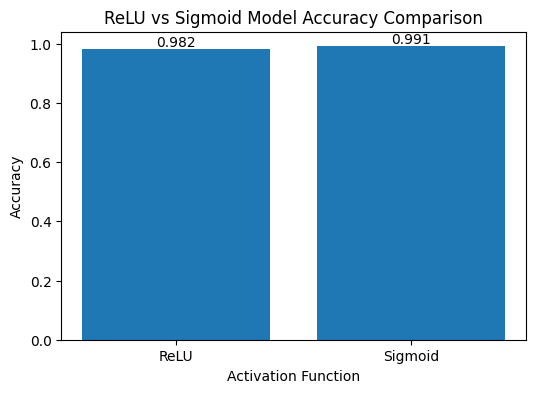

In [19]:
#comparision

models = ['ReLU', 'Sigmoid']
accuracy = [relu_accuracy, sigmoid_accuracy]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.title("ReLU vs Sigmoid Model Accuracy Comparison")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, str(round(v,3)), ha='center')

plt.show()